<a href="https://colab.research.google.com/github/PriscillaAlmeida07/ifood-data-science/blob/main/notebooks/ifood_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Delivery Times Analysis

In [65]:
# Dependencies
# This project uses the following libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Skit Learn
from sklearn.model_selection import train_test_split      # Used to split data into training and testing sets
from sklearn.preprocessing import StandardScaler          # Used for data standardization
from sklearn.preprocessing import LabelEncoder            # Used to perform OneHotEncoding
from sklearn.metrics import accuracy_score                # Used to evaluate the predictive model's accuracy
from sklearn.neighbors import KNeighborsClassifier        # Used to create the model
from imblearn import under_sampling, over_sampling        # Used for data balancing
from imblearn.over_sampling import SMOTE                  # Used for data balancing


### Loading the dataset and checking some key information to get a clear overview for our analysis.

In [66]:
# Loading the file
df_original = pd.read_csv('Food_Delivery_Times.csv', sep=',')

# Create a copy to compare differences later
df_copy = df_original.copy()

In [67]:
# Exploratory analysis

# Display a concise summary of the DataFrame, including data types and non-null values.
print('------------------ Overview ------------------\n')
df_copy.info()

# Calculate and display the count of missing values for each column.
print('\n------------------ Missing values ------------------\n')
print(df_copy.isna().sum())

# Display the first 20 rows of the DataFrame to get a preliminary look at the data.
print('\n------------------ 20 rows ------------------\n')
df_copy.head(20)

------------------ Overview ------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB

------------------ Missing values ------------------

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
V

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57
6,627,9.52,Clear,Low,NaN,Bike,12,1.0,49
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73


###  Splitting numerical and categorical features




In [68]:
numerical_features = df_copy.columns[(df_copy.dtypes == 'int64') | (df_copy.dtypes == 'float64')]
print(f'Numerical features: {numerical_features}')
categorical_features = df_copy.columns[df_copy.dtypes == 'object']
print(f'Categorical features: {categorical_features}')


Numerical features: Index(['Order_ID', 'Distance_km', 'Preparation_Time_min',
       'Courier_Experience_yrs', 'Delivery_Time_min'],
      dtype='object')
Categorical features: Index(['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], dtype='object')


### Analyzing categorical features (columns)




In [69]:
# Analyzing data patterns by grouping each categorical feature
for i in categorical_features:
    print(f'\n------------------ {i} ------------------\n')
    print(df_copy.groupby([i]).size())


------------------ Weather ------------------

Weather
Clear    470
Foggy    103
Rainy    204
Snowy     97
Windy     96
dtype: int64

------------------ Traffic_Level ------------------

Traffic_Level
High      197
Low       383
Medium    390
dtype: int64

------------------ Time_of_Day ------------------

Time_of_Day
Afternoon    284
Evening      293
Morning      308
Night         85
dtype: int64

------------------ Vehicle_Type ------------------

Vehicle_Type
Bike       503
Car        195
Scooter    302
dtype: int64


### Data Visualization with Matplotlib and Seaborn


/tmp/ipykernel_22319/3187040846.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i][0].set_xticklabels(ax[i][0].get_xticklabels(), rotation=45) # Rotaciona os nomes se forem grandes
/tmp/ipykernel_22319/3187040846.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i][0].set_xticklabels(ax[i][0].get_xticklabels(), rotation=45) # Rotaciona os nomes se forem grandes
/tmp/ipykernel_22319/3187040846.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i][0].set_xticklabels(ax[i][0].get_xticklabels(), rotation=45) # Rotaciona os nomes se forem grandes
/tmp/ipykernel_22319/3187040846.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i][0].set

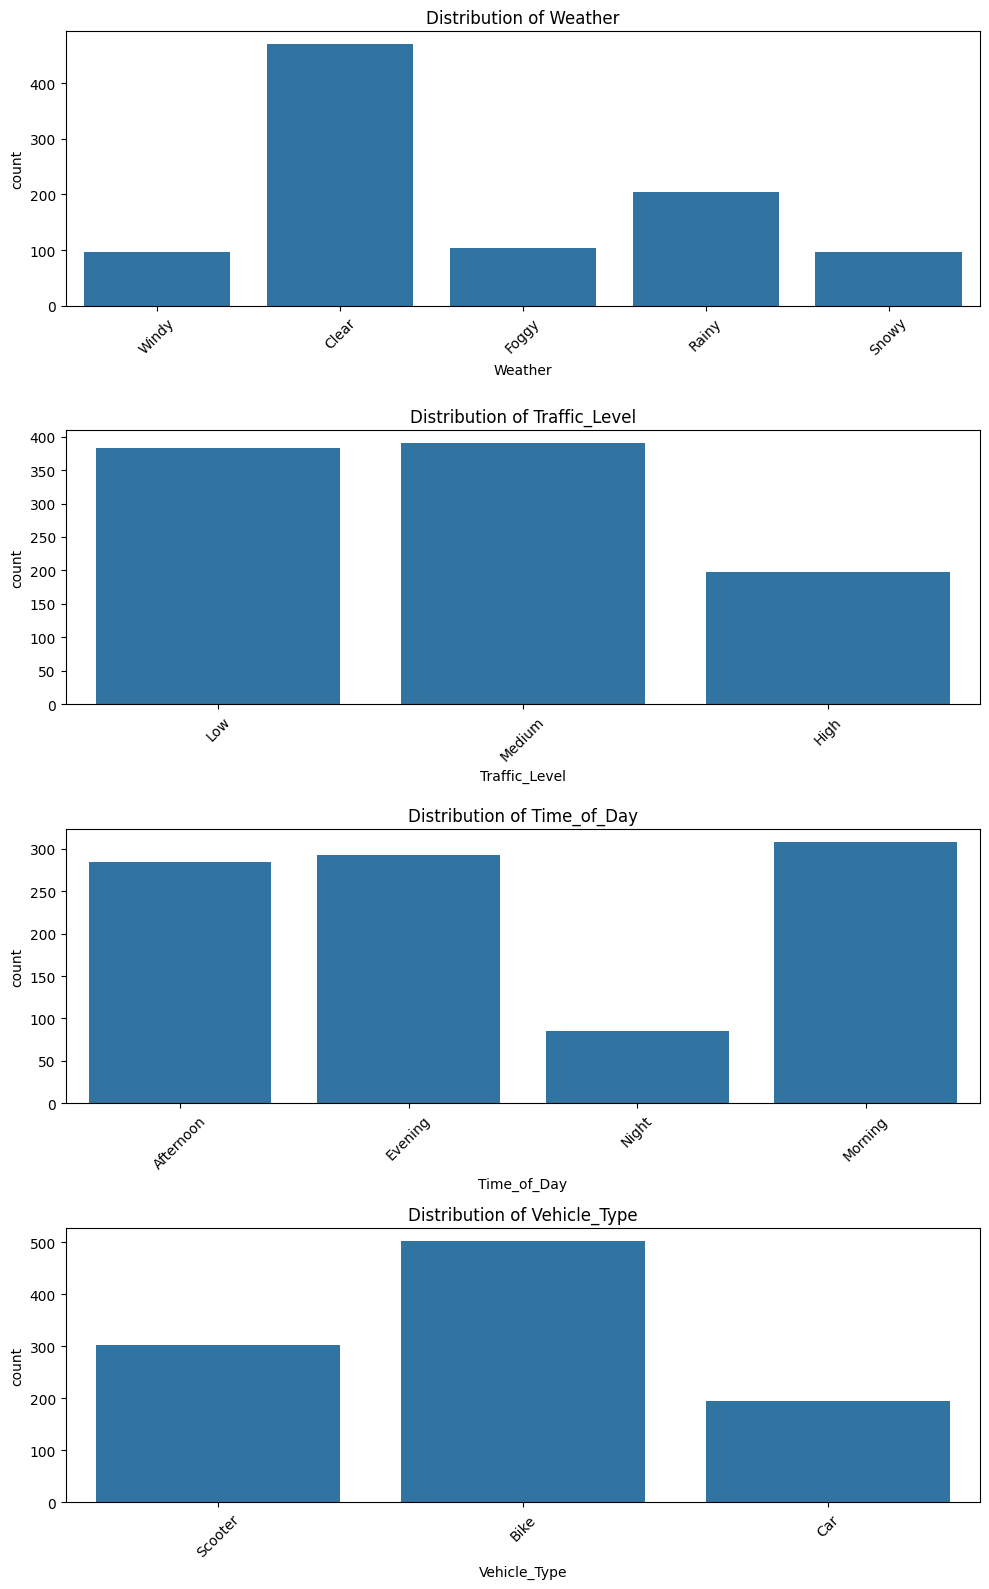

In [70]:
# categorical features
# Visualizing data with bar plots

n = len(categorical_features)

# O argumento squeeze=False garante que 'ax' seja sempre uma lista, mesmo se n=1
fig, ax = plt.subplots(n, 1, figsize=(10, 4 * n), squeeze=False)

for i, column in enumerate(categorical_features):
    # sns.countplot conta os valores e cria as barras automaticamente
    sns.countplot(data=df_copy, x=column, ax=ax[i][0])
    ax[i][0].set_title(f'Distribution of {column}')
    ax[i][0].set_xticklabels(ax[i][0].get_xticklabels(), rotation=45) # Rotaciona os nomes se forem grandes

plt.tight_layout()
plt.show()

### Visualizing outliers

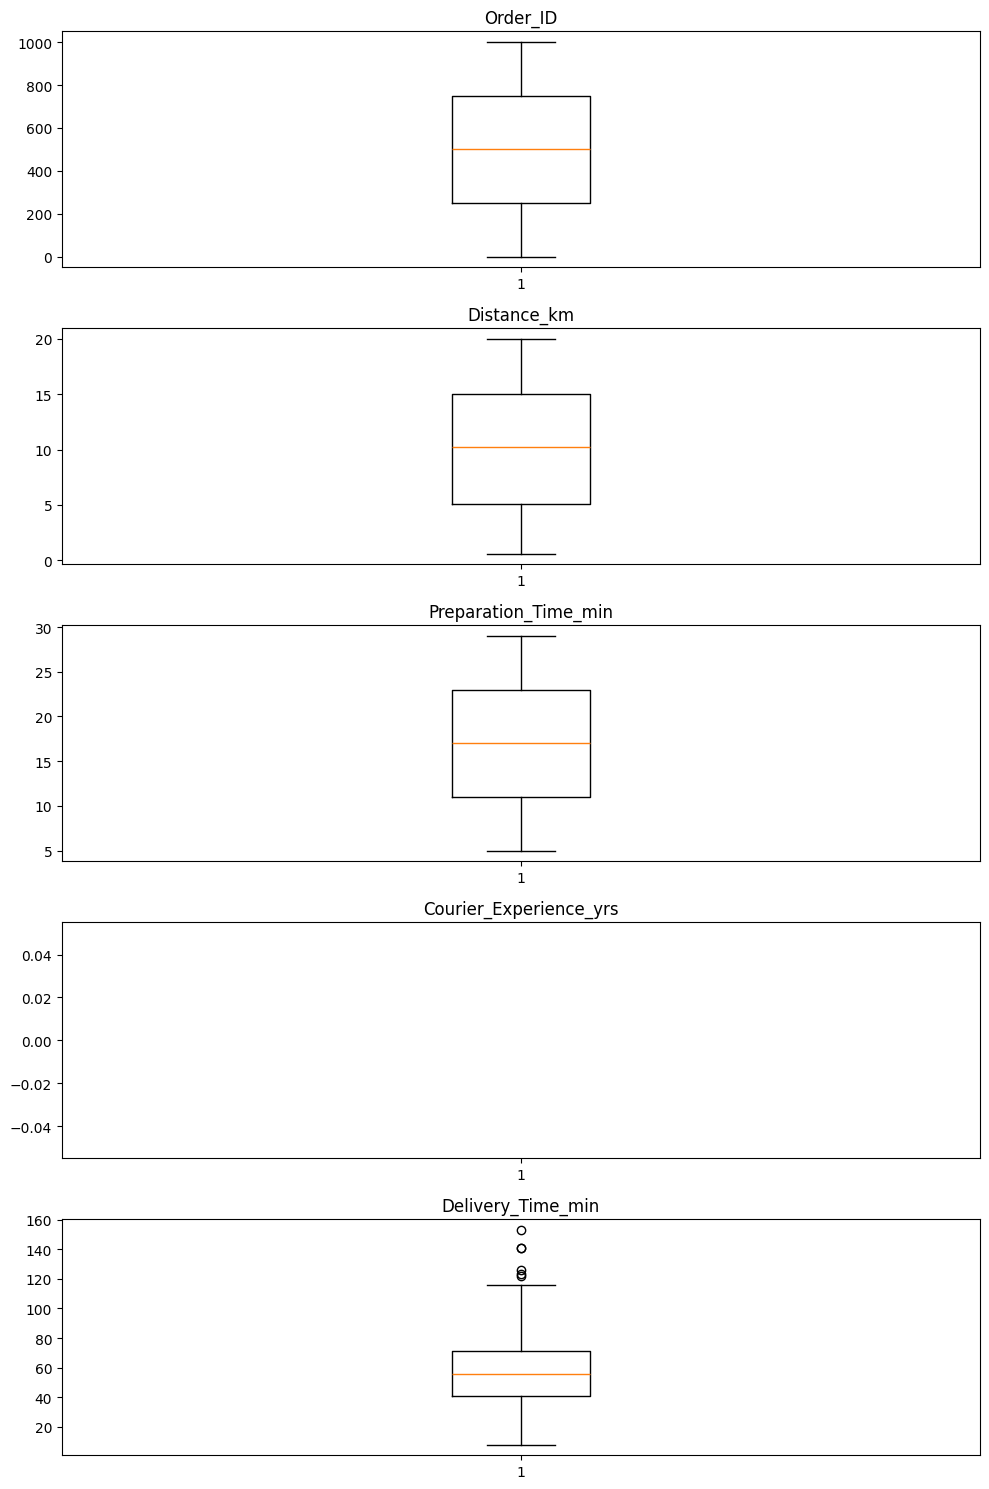

In [71]:
n = len(numerical_features)

fig, ax = plt.subplots(n, figsize=(10, 3*n))

for i, column in enumerate(numerical_features):
    ax[i].boxplot(df_copy[column])
    ax[i].set_title(column)

plt.tight_layout()
plt.show()


 ### Handling outliers

(994, 9)


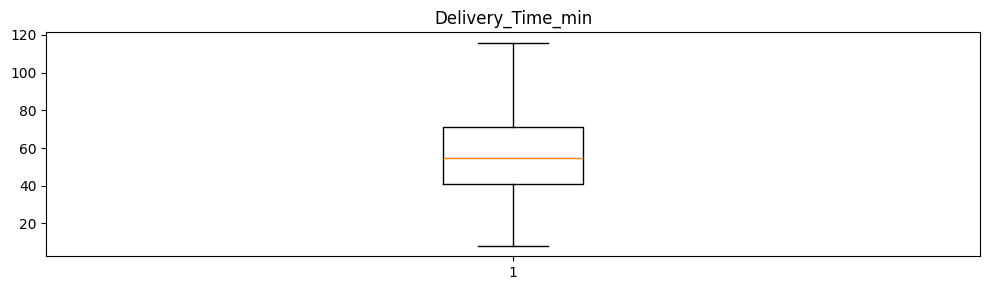

In [72]:
## Handling Delivery Time outliers
df1 = df_copy.loc[df_copy['Delivery_Time_min'] <= 120]
print(df1.shape)

fig, ax = plt.subplots(figsize=(10, 3))

ax.boxplot(df1['Delivery_Time_min'])
ax.set_title('Delivery_Time_min')

plt.tight_layout()
plt.show()


### Handle missing data.

In [73]:
df2 = df1.fillna('NA')

# Display the first 10 rows of the DataFrame to verify the missing value imputation.
print(f'\n------------------ info ------------------\n')
df2.info()

print(f'\n------------------ are there any missing values yet? ------------------\n')
print(df2.isna().sum())


------------------ info ------------------

<class 'pandas.core.frame.DataFrame'>
Index: 994 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                994 non-null    int64  
 1   Distance_km             994 non-null    float64
 2   Weather                 994 non-null    object 
 3   Traffic_Level           994 non-null    object 
 4   Time_of_Day             994 non-null    object 
 5   Vehicle_Type            994 non-null    object 
 6   Preparation_Time_min    994 non-null    int64  
 7   Courier_Experience_yrs  994 non-null    object 
 8   Delivery_Time_min       994 non-null    int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 77.7+ KB

------------------ are there any missing values yet? ------------------

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day             

### Checking duplicate rows

In [74]:
# Check for duplicate rows in the DataFrame.
df2.duplicated().sum()
# Conclusion: The output of 0 confirms that there are no duplicate entries in the dataset.

np.int64(0)

# Data Analysis


### 1 - Correlation

In [75]:
# Calculate the Pearson correlation coefficient between 'Distance_km' and 'Delivery_Time_min'.
correlation = df2['Distance_km'].corr(df2['Delivery_Time_min'])
print(f'Correlation between Distance_km and Delivery_Time_min:', correlation)
# Compute correlations for all numerical columns with 'Delivery_Time_min' and sort them in descending order.
df2.corr(numeric_only=True)['Delivery_Time_min'].sort_values(ascending=False)

# Conclusion: 'Distance_km' exhibits the strongest positive correlation with 'Delivery_Time_min'.
# This implies that as the delivery distance increases, the delivery time tends to increase proportionally.

Correlation between Distance_km and Delivery_Time_min: 0.7883433012095028


,Delivery_Time_min
Delivery_Time_min,1.000000
Distance_km,0.788343
Preparation_Time_min,0.307307
Order_ID,-0.043732


### 2 -

In [76]:
# Analyze the influence of categorical variables on 'Delivery_Time_min' by calculating the mean delivery time for each category.
# Group by 'Weather' and calculate the mean 'Delivery_Time_min', sorted in descending order.
df2.groupby('Weather')['Delivery_Time_min'].mean().sort_values(ascending=False)
# Group by 'Traffic_Level' and calculate the mean 'Delivery_Time_min', sorted in descending order.
df2.groupby('Traffic_Level')['Delivery_Time_min'].mean().sort_values(ascending=False)
# Group by 'Vehicle_Type' and calculate the mean 'Delivery_Time_min', sorted in descending order.
df2.groupby('Vehicle_Type')['Delivery_Time_min'].mean().sort_values(ascending=False)
# Group by 'Time_of_Day' and calculate the mean 'Delivery_Time_min', sorted in descending order.
df2.groupby('Time_of_Day')['Delivery_Time_min'].mean().sort_values(ascending=False)

,Delivery_Time_min
Time_of_Day,
NA,60.392857
Evening,56.744828
Afternoon,56.080986
Morning,55.892508
Night,55.211765


### View